In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
from sklearn.metrics import mean_squared_error
from sklearn.utils import resample
import os

In [2]:
#plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=24)
plt.rc('xtick', labelsize=18)
plt.rc('ytick', labelsize=18)
plt.rc('axes', labelsize=18)
plt.rc('text', usetex=True)

In [3]:
from ase import Atoms

In [4]:
from sklearn.linear_model import LinearRegression

In [5]:
ValidationBS = pd.read_pickle('validation_data/FullyCuratedParsedBriefSummary.pkl')

In [6]:
ValidationBS#.head()#.columns

,Mag,,Phase,name,status,relax,murnaghan,relax_optimized_structure,relax_energy,relax_forces,...,B,fit,xc,encut,deltak,ncrash,nelem,EF,x_Fe,x_Mo
Fe_pv56.delta-AAAAAAAAAAAAAA.NM,NM,delta-AAAAAAAAAAAAAA,delta,VASP_PBE_500_0.125_0.1_NM/Fe/delta/Fe_pv56.del...,finished,finished,finished,"{'numbers': [26, 26, 26, 26, 26, 26, 26, 26, 2...",-448.707000,"[[0.00134237, -0.00094035, -0.00018561], [0.00...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.171448,1.000000,0.000000
Fe_pv48Mo_sv8.delta-BBAAAAAAAAAAAA.NM,NM,delta-BBAAAAAAAAAAAA,delta,VASP_PBE_500_0.125_0.1_NM/FeMo/delta/Fe_pv48Mo...,finished,finished,finished,"{'numbers': [42, 42, 42, 42, 42, 42, 42, 42, 2...",-474.228176,"[[-0.00211024, 0.00027539, -0.00019051], [-0.0...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.108389,0.857143,0.142857
Fe_pv20Mo_sv36.delta-BBBBBBBBAAABAA.NM,NM,delta-BBBBBBBBAAABAA,delta,VASP_PBE_500_0.125_0.1_NM/FeMo/delta/Fe_pv20Mo...,finished,finished,finished,"{'numbers': [42, 42, 42, 42, 42, 42, 42, 42, 4...",-554.893090,"[[0.00032864, 0.00115415, -0.00107401], [0.000...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.04232,0.357143,0.642857
Fe_pv52Mo_sv4.delta-AABAAAAAAAAAAA.NM,NM,delta-AABAAAAAAAAAAA,delta,VASP_PBE_500_0.125_0.1_NM/FeMo/delta/Fe_pv52Mo...,finished,finished,finished,"{'numbers': [26, 26, 26, 26, 26, 26, 26, 26, 4...",-462.560867,"[[-0.00081084, 0.00079078, -0.00207556], [-0.0...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.120397,0.928571,0.071429
Fe_pv48Mo_sv8.delta-BABAAAAAAAAAAA.NM,NM,delta-BABAAAAAAAAAAA,delta,VASP_PBE_500_0.125_0.1_NM/FeMo/delta/Fe_pv48Mo...,finished,finished,finished,"{'numbers': [42, 42, 42, 42, 26, 26, 26, 26, 4...",-475.020728,"[[-0.00108605, -0.0021022, 0.00095467], [-0.00...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.09424,0.857143,0.142857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv52Mo_sv4.delta-AABAAAAAAAAAAA.NM,NaN,bulk delta-AABAAAAAAAAAAA,delta,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,277.152251 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2.0,0.112246,0.928571,0.071429
Fe_pv56.P.NM,NaN,bulk P,P,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,272.113990 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1.0,0.199295,1.000000,0.000000
Fe_pv56.delta.NM,NaN,bulk delta,delta,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,274.874823 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1.0,0.160998,1.000000,0.000000
Fe_pv6Mo_sv47.R-BBBBBABBBBB.NM,NaN,bulk R-BBBBBABBBBB,R,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,246.893484 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2.0,0.227291,0.113208,0.886792


In [7]:
prediction_data_files = glob.glob('Fe-Mo/results/PREDICTION__*')

In [8]:
PredictionValues = {}

In [9]:
for file in prediction_data_files:
    if 'old' in file:
        continue
    label, phase, model_with_params = file.replace('.csv','').split('__')
    PredictionValues[(model_with_params, phase)] = pd.read_csv(file, header=0, index_col=0)

# comparisions

In [10]:
def get_confidence_intervals (regression_model, x, y, n_bootstraps = 1000 ):
    bootstrapped_predictions = np.empty((n_bootstraps, len(x)))
    for i in range(n_bootstraps):
        # Resample the data with replacement
        x_resampled, y_resampled = resample(x, y)
        # Fit the model to the resampled data
        regression_model.fit(x_resampled.reshape(-1, 1), y_resampled)
        # Predict
        bootstrapped_predictions[i] = regression_model.predict(x.reshape(-1, 1))
        lower_ci = np.percentile(bootstrapped_predictions, 2.5, axis=0)
        upper_ci = np.percentile(bootstrapped_predictions, 97.5, axis=0)
    return lower_ci, upper_ci

In [11]:
def plot_with_ci(ytrue, ypred, ax = None):
    sorter = ytrue.values.argsort()
    regressor = LinearRegression()
    regressor.fit(ytrue.values.reshape(-1,1), ypred.values.reshape(-1,1))
    x_y_y = regressor.predict(ytrue.values.reshape(-1,1))
    lower_ci, upper_ci = get_confidence_intervals(LinearRegression(), ytrue.values.astype(float), ypred.values.astype(float))
    if ax is None:
        fig, ax = plt.subplots()
    ax.scatter(ytrue, ypred)
    ax.plot(ytrue.values, x_y_y.ravel())#, upper_ci)
    ax.fill_between(ytrue.values.astype(float)[sorter], lower_ci[sorter], upper_ci[sorter], alpha=0.5)
    return ax

In [12]:
def get_model_position(modelname):
    if 'projections' in modelname:
        return 0
    elif 'ACE' in modelname:
        return 1
    elif 'SOAP' in modelname:
        return 2

In [13]:
phase_position = {'R': 0, 'P' : 2, 'M': 1, 'delta': 3}

In [14]:
phase_label = {'R': 'R', 'P': 'P', 'M': 'M', 'delta': r'$\delta$'}

In [15]:
rmse_tag = {(0,0): 'rmse = '}

SOAP_specific_small M EF_nmhcp__SOAP_specific_small
SOAP_specific_small R EF_nmhcp__SOAP_specific_small
ACE R EF_nmhcp__ACE
0.7dprojections_0.5os delta EF_nmhcp__0.7dprojections_0.5os
SOAP_specific_small P EF_nmhcp__SOAP_specific_small
0.7dprojections_0.5os P EF_nmhcp__0.7dprojections_0.5os
SOAP_specific_small delta EF_nmhcp__SOAP_specific_small
0.7dprojections_0.5os M EF_nmhcp__0.7dprojections_0.5os
ACE M EF_nmhcp__ACE
0.7dprojections_0.5os R EF_nmhcp__0.7dprojections_0.5os
ACE delta EF_nmhcp__ACE
ACE P EF_nmhcp__ACE


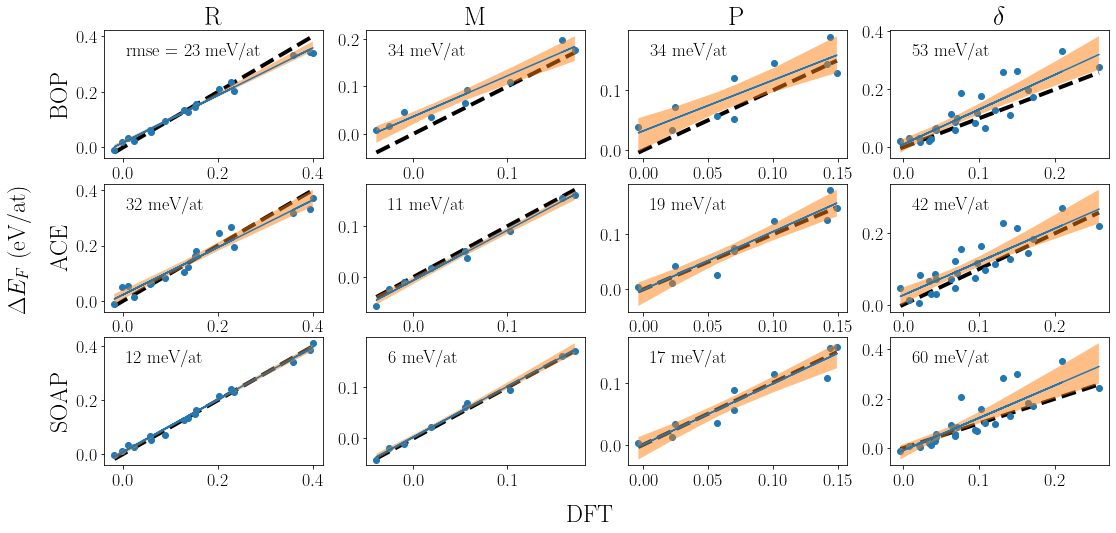

In [18]:
figsize = plt.rcParams['figure.figsize']
fig, ax = plt.subplots(3, len(phase_position), figsize=(figsize[0]*3, figsize[1]*2))
rmse = {}
for (model, phase), prediction_values in PredictionValues.items():
    model_name = model.replace('_16','').replace('_lmax=321','').replace('_small_specific','_small')
    target_name = f'EF_nmhcp__{model_name}'
    print(model_name, phase, target_name)
    this_validation_data = ValidationBS.query('Phase == "'+phase+'"')['EF']
    this_validation_data = this_validation_data.loc[~this_validation_data.index.duplicated(keep='first')]
    predictions_with_validation = prediction_values.index.intersection(this_validation_data.index)
    ytrue = this_validation_data[predictions_with_validation]
    ypred = prediction_values[target_name][predictions_with_validation]
    rmse[(model, phase)] = mean_squared_error(ytrue, ypred, squared=False)
    this_rmse = rmse[(model, phase)]
    I = get_model_position(model_name)
    J = phase_position[phase]
    ax[I,J] = plot_with_ci(ytrue, ypred, ax=ax[I,J])
    this_rmse_label = rf'{rmse_tag.get((I,J), "")}{this_rmse*1000 :.0f} meV/at'
    ax[I,J].annotate(this_rmse_label,(0.1, 0.8), xycoords='axes fraction', fontsize = 18)
    if I == 0:
        ax[I,J].set_title(phase_label.get(phase), fontsize = 26)
    ax[I,J].plot([ytrue.min(), ytrue.max()], [ytrue.min(), ytrue.max()], '--k', linewidth=4, zorder = -10)
ylabel_bop =ax[get_model_position('projections'),0].set_ylabel('BOP', fontsize=24)
ylabel_ACE =ax[get_model_position('ACE'), 0].set_ylabel('ACE', fontsize=24)
ylabel_SOAP =ax[get_model_position('SOAP'), 0].set_ylabel('SOAP', fontsize=24)
fig.supxlabel('DFT', fontsize=24, y=0.02)
fig.supylabel('$\Delta E_F$ (eV/at)', fontsize=24, x=0.05)
fig.savefig('Fe-Mo/graphs/Predictions_Validation.pdf')

In [25]:
PredictionValues.keys()

dict_keys([('ACE_lmax=321', 'R'), ('SOAP_specific_small_specific', 'delta'), ('SOAP_specific_small_specific', 'M'), ('ACE_lmax=321', 'delta'), ('0.7dprojections_0.5os_16', 'R'), ('0.7dprojections_0.5os_16', 'M'), ('SOAP_specific_small_specific', 'P'), ('0.7dprojections_0.5os_16', 'delta'), ('ACE_lmax=321', 'P'), ('ACE_lmax=321', 'M'), ('0.7dprojections_0.5os_16', 'P'), ('SOAP_specific_small_specific', 'R')])

In [26]:
for (model, phase), prediction_values in PredictionValues.items():
    break

In [31]:
phase

'R'

In [27]:
prediction_values

,EF_nmhcp__ACE,vote_0,vote_1,vote_2,vote_3,vote_4,vote_5,vote_6,vote_7,vote_8,vote_9,vote_10,vote_11,std_votes
Fe_pv53.R.NM,0.168231,0.167276,0.166952,0.167203,0.167940,0.166907,0.165606,0.177566,0.166085,0.165555,0.172603,0.168454,0.166627,0.003477
Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM,0.086116,0.084114,0.090006,0.083445,0.092468,0.087152,0.083180,0.091091,0.082675,0.083757,0.086404,0.087623,0.081476,0.003598
Fe_pv51Mo_sv2.R-AAAAAAAAABA.NM,0.138999,0.139423,0.137477,0.138559,0.136145,0.140442,0.141152,0.144332,0.139726,0.140798,0.136447,0.132789,0.140700,0.002981
Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM,0.063679,0.064359,0.065604,0.062590,0.061642,0.065203,0.063444,0.059343,0.061903,0.063694,0.065153,0.066719,0.064488,0.002043
Fe_pv47Mo_sv6.R-AAAAAAAABAA.NM,0.102686,0.081215,0.095973,0.096162,0.095746,0.099644,0.123436,0.129217,0.102475,0.095145,0.098218,0.109022,0.105984,0.013033
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv6Mo_sv47.R-BBBBBBBBABB.NM,0.373295,0.376047,0.360746,0.386137,0.378640,0.346875,0.370763,0.371394,0.368725,0.369070,0.399493,0.376790,0.374864,0.012814
Fe_pv8Mo_sv45.R-BBBBBBBBBAA.NM,0.451276,0.460046,0.447379,0.452355,0.438460,0.448915,0.447854,0.456496,0.450562,0.456599,0.440095,0.456428,0.460125,0.007140
Fe_pv2Mo_sv51.R-BBBBBBBBBAB.NM,0.348404,0.356777,0.328228,0.345357,0.351569,0.350105,0.345887,0.352158,0.351340,0.343539,0.346149,0.356050,0.353694,0.007649
Fe_pv6Mo_sv47.R-BBBBBBBBBBA.NM,0.412303,0.413248,0.404558,0.419683,0.411011,0.407305,0.415347,0.414016,0.415773,0.414010,0.413253,0.411682,0.407754,0.004168


In [34]:
sorted_validation = ValidationBS.query(f'Phase == "{phase}"').sort_values(by='x_Fe')

In [40]:
validated_samples = prediction_values.index.intersection(sorted_validation.index)

In [43]:
prediction_values.loc[validated_samples]

,EF_nmhcp__ACE,vote_0,vote_1,vote_2,vote_3,vote_4,vote_5,vote_6,vote_7,vote_8,vote_9,vote_10,vote_11,std_votes
Fe_pv47Mo_sv6.R-AAAAAAAABAA.NM,0.102686,0.081215,0.095973,0.096162,0.095746,0.099644,0.123436,0.129217,0.102475,0.095145,0.098218,0.109022,0.105984,0.013033
Fe_pv39Mo_sv14.R-AAAAAAABABB.NM,0.054983,0.064192,0.065451,0.021502,0.073398,0.054576,0.056757,0.059231,0.052939,0.063312,0.064304,0.049561,0.034579,0.014403
Fe_pv33Mo_sv20.R-AAAAAABBABB.NM,0.049330,0.049820,0.020658,0.031635,0.057650,0.068831,0.042003,0.032245,0.076801,0.048975,0.114482,0.016790,0.032071,0.027447
Fe_pv35Mo_sv18.R-AAAAAABBBAA.NM,0.081259,0.070717,0.069100,0.125170,0.186807,0.053073,0.019350,0.075191,0.086683,0.040602,0.098804,0.101879,0.047729,0.044242
Fe_pv47Mo_sv6.R-AAAABAAAAAA.NM,0.193063,0.197111,0.167559,0.185766,0.186298,0.213749,0.199772,0.205046,0.182505,0.215006,0.185479,0.201641,0.176820,0.014679
Fe_pv19Mo_sv34.R-ABABAABBBBB.NM,0.064956,0.060527,0.055734,0.050115,0.060763,0.100846,0.071563,0.046215,0.073229,0.065142,0.048726,0.074324,0.072293,0.015072
Fe_pv13Mo_sv40.R-ABABBABBBBB.NM,0.162562,0.165249,0.144032,0.148635,0.153214,0.191721,0.171474,0.148406,0.157588,0.166024,0.167677,0.166415,0.170307,0.013142
Fe_pv50Mo_sv3.R-BAAAAAAAABA.NM,0.124084,0.124785,0.123539,0.122650,0.100572,0.124268,0.119932,0.137358,0.128111,0.141955,0.116132,0.131669,0.118039,0.010626
Fe_pv38Mo_sv15.R-BAAAAAAABBB.NM,0.013287,0.014575,0.011246,0.026731,0.005190,0.009603,0.021458,0.003043,-0.007024,0.034743,0.003069,0.010942,0.025869,0.011979
Fe_pv32Mo_sv21.R-BAAAAAABBBB.NM,-0.011542,-0.021883,-0.003585,-0.021505,-0.017458,-0.006795,-0.013989,-0.005186,-0.016515,-0.003146,-0.023003,-0.011859,0.006421,0.009159


In [46]:
prediction_values.loc[validated_samples]['EF_nmhcp__ACE']

Fe_pv47Mo_sv6.R-AAAAAAAABAA.NM     0.102686
Fe_pv39Mo_sv14.R-AAAAAAABABB.NM    0.054983
Fe_pv33Mo_sv20.R-AAAAAABBABB.NM    0.049330
Fe_pv35Mo_sv18.R-AAAAAABBBAA.NM    0.081259
Fe_pv47Mo_sv6.R-AAAABAAAAAA.NM     0.193063
Fe_pv19Mo_sv34.R-ABABAABBBBB.NM    0.064956
Fe_pv13Mo_sv40.R-ABABBABBBBB.NM    0.162562
Fe_pv50Mo_sv3.R-BAAAAAAAABA.NM     0.124084
Fe_pv38Mo_sv15.R-BAAAAAAABBB.NM    0.013287
Fe_pv32Mo_sv21.R-BAAAAAABBBB.NM   -0.011542
Fe_pv20Mo_sv33.R-BAAABABBBBB.NM    0.061251
Fe_pv8Mo_sv45.R-BABBBABBBBB.NM     0.243735
Fe_pv12Mo_sv41.R-BBABBABBBBB.NM    0.180155
Fe_pv6Mo_sv47.R-BBBBBABBBBB.NM     0.265359
Fe_pv18Mo_sv35.R-BBBBBBAAABB.NM    0.333385
Fe_pv12Mo_sv41.R-BBBBBBAABBB.NM    0.316432
Fe_pv6Mo_sv47.R-BBBBBBBBABB.NM     0.373295
Name: EF_nmhcp__ACE, dtype: float64

In [51]:
ValidationBS.loc[validated_samples]['x_Fe']

Fe_pv47Mo_sv6.R-AAAAAAAABAA.NM     0.886792
Fe_pv39Mo_sv14.R-AAAAAAABABB.NM    0.735849
Fe_pv33Mo_sv20.R-AAAAAABBABB.NM    0.622642
Fe_pv35Mo_sv18.R-AAAAAABBBAA.NM    0.660377
Fe_pv47Mo_sv6.R-AAAABAAAAAA.NM     0.886792
Fe_pv19Mo_sv34.R-ABABAABBBBB.NM    0.358491
Fe_pv13Mo_sv40.R-ABABBABBBBB.NM    0.245283
Fe_pv50Mo_sv3.R-BAAAAAAAABA.NM     0.943396
Fe_pv38Mo_sv15.R-BAAAAAAABBB.NM    0.716981
Fe_pv32Mo_sv21.R-BAAAAAABBBB.NM    0.603774
Fe_pv20Mo_sv33.R-BAAABABBBBB.NM    0.377358
Fe_pv8Mo_sv45.R-BABBBABBBBB.NM     0.150943
Fe_pv12Mo_sv41.R-BBABBABBBBB.NM    0.226415
Fe_pv6Mo_sv47.R-BBBBBABBBBB.NM     0.113208
Fe_pv18Mo_sv35.R-BBBBBBAAABB.NM    0.339623
Fe_pv12Mo_sv41.R-BBBBBBAABBB.NM    0.226415
Fe_pv6Mo_sv47.R-BBBBBBBBABB.NM     0.113208
Name: x_Fe, dtype: float64

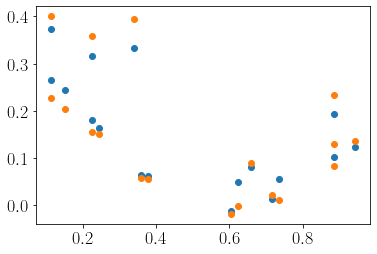

In [53]:
plt.scatter(ValidationBS.loc[validated_samples]['x_Fe'], prediction_values.loc[validated_samples]['EF_nmhcp__ACE'])
plt.scatter(sorted_validation['x_Fe'], sorted_validation['EF'])

In [17]:
BS = pd.read_pickle('Fe-Mo/FullyCuratedParsedBriefSummary.pkl')

In [18]:
BS

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,Mag,Phase,EF_fmbcc,EF_nmhcp,EF_nmfcc
Fe_pv4Mo_sv20.C36-ABBBB.FM,bulk C36-ABBBB.FM,16.270923 A,-10.007837,204.470374 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,4,20,24,0.166667,0.833333,FM,C36,0.478663,0.478663,0.478663
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,bulk R-AAAABBBBBBB,14.436090 A,-10.020954,255.953497 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,15,38,53,0.283019,0.716981,NM,R,0.154058,0.133919,0.111544
Fe_pv2Mo_sv11.mu-BBABB.FM,bulk mu-BBABB.FM,16.007021 A,-10.117556,215.396114 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,2,11,13,0.153846,0.846154,FM,mu,0.403272,0.403272,0.403272
Fe_pv8Mo_sv22.sigma-BBBAB.NM,bulk sigma-BBBAB,14.426681 A,-10.141531,260.386848 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,8,22,30,0.266667,0.733333,NM,sigma,0.077265,0.058290,0.037208
Fe_pv2Mo_sv11.mu-BBBBA.NM,bulk mu-BBBBA,15.656633 A,-10.146330,235.078776 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,2,11,13,0.153846,0.846154,NM,mu,0.374554,0.363607,0.351444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv6.C15.FM,bulk C15.FM,12.092153 A,-8.111059,148.116428 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.021,0,1,...,6,0,6,1.000000,0.000000,FM,C15,0.144169,0.144169,0.144169
Mo_sv1.bcc.NM,bulk bcc,15.828881 A,-10.932821,259.504388 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.016,0,1,...,1,0,1,0.000000,1.000000,NM,bcc,0.000000,0.000000,0.000000
Mo_sv8.A15.NM,bulk A15,16.079860 A,-10.837515,253.234487 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.016,0,1,...,8,0,8,0.000000,1.000000,NM,A15,0.095306,0.095306,0.095306
Mo_sv1.fcc.NM,bulk fcc,16.059116 A,-10.511038,239.489255 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.012,0,1,...,1,0,1,0.000000,1.000000,NM,fcc,0.421784,0.421784,0.421784


In [19]:
BS.query('Phase == "R"')[['Mo_sv', 'Fe_pv', 'EF_nmhcp']].sort_values('Mo_sv')

,Mo_sv,Fe_pv,EF_nmhcp
Fe_pv53.R.NM,0.000000,1.000000,0.165564
Fe_pv52Mo_sv1.R-BAAAAAAAAAA.NM,0.018868,0.981132,0.159020
Fe_pv51Mo_sv2.R-AAAAAAAAABA.NM,0.037736,0.962264,0.141516
Fe_pv50Mo_sv3.R-BBAAAAAAAAA.NM,0.056604,0.943396,0.163120
Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM,0.113208,0.886792,0.082154
Fe_pv46Mo_sv7.R-BAAAAAABAAA.NM,0.132075,0.867925,0.130365
Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM,0.150943,0.849057,0.063301
Fe_pv43Mo_sv10.R-ABAAAAAAABB.NM,0.188679,0.811321,0.075235
Fe_pv39Mo_sv14.R-AAAABAAAABB.NM,0.264151,0.735849,0.160439
Fe_pv39Mo_sv14.R-AAAAAAAABBB.NM,0.264151,0.735849,0.028865


In [20]:
ValidationBS.query('Phase == "R"')

,Mag,,Phase,name,status,relax,murnaghan,relax_optimized_structure,relax_energy,relax_forces,...,B,fit,xc,encut,deltak,ncrash,nelem,EF,x_Fe,x_Mo
Fe_pv12Mo_sv41.R-BBABBABBBBB.NM,NaN,bulk R-BBABBABBBBB,R,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,252.670511 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2.0,0.154728,0.226415,0.773585
Fe_pv12Mo_sv41.R-BBBBBBAABBB.NM,NaN,bulk R-BBBBBBAABBB,R,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,236.397567 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2.0,0.357897,0.226415,0.773585
Fe_pv13Mo_sv40.R-ABABBABBBBB.NM,NaN,bulk R-ABABBABBBBB,R,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,253.012900 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2.0,0.151223,0.245283,0.754717
Fe_pv18Mo_sv35.R-BBBBBBAAABB.NM,NaN,bulk R-BBBBBBAAABB,R,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,234.546435 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2.0,0.394281,0.339623,0.660377
Fe_pv32Mo_sv21.R-BAAAAAABBBB.NM,NaN,bulk R-BAAAAAABBBB,R,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,275.487135 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2.0,-0.018594,0.603774,0.396226
Fe_pv33Mo_sv20.R-AAAAAABBABB.NM,NaN,bulk R-AAAAAABBABB,R,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,273.315503 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2.0,-0.002643,0.622642,0.377358
Fe_pv35Mo_sv18.R-AAAAAABBBAA.NM,NaN,bulk R-AAAAAABBBAA,R,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,266.674759 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2.0,0.089326,0.660377,0.339623
Fe_pv39Mo_sv14.R-AAAAAAABABB.NM,NaN,bulk R-AAAAAAABABB,R,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,277.108833 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2.0,0.010848,0.735849,0.264151
Fe_pv47Mo_sv6.R-AAAAAAAABAA.NM,NaN,bulk R-AAAAAAAABAA,R,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,270.691202 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2.0,0.12929,0.886792,0.113208
Fe_pv47Mo_sv6.R-AAAAAABBAAA.NM,NaN,bulk R-AAAAAABBAAA,R,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,277.368564 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2.0,0.082163,0.886792,0.113208


In [21]:
plt.scatter(dft_chull['x_Mo'], dft_chull['EF'])

NameError: name 'dft_chull' is not defined